# Image Preprocessing Experiments for all CNNS

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [2]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [3]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 428 (delta 76), reused 128 (delta 46), pack-reused 222 (from 1)
Receiving objects: 100% (428/428), 15.47 MiB | 21.58 MiB/s, done.
Resolving deltas: 100% (181/181), done.
/content/CM3070_Final_Project


In [4]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [5]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessing_pipelines import *
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import *
from src.dataset.data_augmentation import *
from src.models.vgg16CNN import create_vgg16_model
from src.models.resnet50CNN import create_resnet50_model
from src.models.mobilenetv2CNN import create_mobilenetv2_model
from src.models.densenet121CNN import create_densenet121_model
from src.models.efficientnetb0CNN import create_efficientnetb0_model
from src.visualizations import *

In [6]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [8]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [9]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [10]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [11]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64


In [12]:
# Validation set true labels for evaluation
val_true_labels = val_df['pathology'].to_numpy()

In [13]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_results.csv"

In [14]:
# Constants
BATCH_SIZE = 32
BUFFER_SIZE = len(train_df)
TOTAL_TRAINING_SAMPLES = len(train_df)
CLASSES = 2
PREDICTION_THRESHOLD = 0.5
EPOCHS = 20

In [15]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [16]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df, CLASSES, TOTAL_TRAINING_SAMPLES)

## CLAHE + Median Blur Image Preprocessing Experiment

#### tf.data Dataset Preparation for CLAHE + Median Blur Preprocessing

In [20]:
# CLAHE + Median Blur + Baseline (resizing + model-specific normalization) preprocessing
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

In [23]:
# Generate training dataset for the current image preprocessor
train_dataset_exp1 = generate_dataset(train_df, clahe_median_blur_preprocessor)
# Shuffle training dataset samples
train_dataset_exp1 = shuffle_training_dataset(train_dataset_exp1, BUFFER_SIZE)
# Add data augmentation to training dataset
train_dataset_exp1 = data_augmented_dataset(train_dataset_exp1)
# Batch and prefetch the dataset
train_dataset_exp1 = batch_dataset(train_dataset_exp1, BATCH_SIZE)

# Generate validation dataset for the current image preprocessor
val_dataset_exp1 = generate_dataset(val_df, clahe_median_blur_preprocessor)
# Batch and prefetch the validation dataset
val_dataset_exp1 = batch_dataset(val_dataset_exp1, BATCH_SIZE)

### VGG16

In [24]:
# Create a VGG16 model instance and compile it
vgg16_model_exp1 = create_vgg16_model()
vgg16_model_exp1 = compile_model(vgg16_model_exp1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
# Print vgg16 model summary
vgg16_model_exp1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
# Train VGG16 with training dataset for CLAHE + Median Blur preprocessor
vgg16_model_exp1.fit(
    train_dataset_exp1,
    validation_data=val_dataset_exp1,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 527ms/step - accuracy: 0.5446 - auc: 0.5265 - loss: 1.0205 - precision: 0.4310 - recall: 0.4558 - val_accuracy: 0.5945 - val_auc: 0.5741 - val_loss: 0.7055 - val_precision: 0.4730 - val_recall: 0.3043
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 503ms/step - accuracy: 0.6070 - auc: 0.5950 - loss: 0.8119 - precision: 0.5058 - recall: 0.4845 - val_accuracy: 0.5980 - val_auc: 0.6019 - val_loss: 0.7085 - val_precision: 0.4860 - val_recall: 0.4522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 502ms/step - accuracy: 0.6022 - auc: 0.5882 - loss: 0.7877 - precision: 0.4994 - recall: 0.4535 - val_accuracy: 0.6286 - val_auc: 0.6008 - val_loss: 0.6467 - val_precision: 0.5556 - val_recall: 0.2609
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 505ms/step - accuracy: 0.6273 - auc: 0.6177 - loss: 0.7246 - precision: 0.5373 - recall: 0.4458 - val_accuracy: 0.6201 - val_auc: 0.6519 - val_loss: 0.6881 - val_precision: 0.5141 - val_recall: 0.5565
Epoch 5/20
72/72 ━━━━━━━━━━━

In [27]:
# Get validation logits
val_logits_vgg_exp1 = vgg16_model_exp1.predict(val_dataset_exp1)

# Get validation probabilities
val_probabilities_vgg_exp1 = tf.nn.sigmoid(val_logits_vgg_exp1)

# Get validation dataset predictions
val_predictions_vgg_exp1 = tf.cast(val_probabilities_vgg_exp1 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step


In [30]:
# Evaluation metrics
eval_metrics_vgg_exp1 = vgg16_model_exp1.evaluate(val_dataset_exp1, return_dict=True)
# F1 Score
f1_score_vgg_exp1 = compute_f1_score(eval_metrics_vgg_exp1['precision'], eval_metrics_vgg_exp1['recall'])
# Confusion Matrix
tn_vgg_exp1, fp_vgg_exp1, fn_vgg_exp1, tp_vgg_exp1 = confusion_matrix(val_true_labels, val_predictions_vgg_exp1).ravel()
# Specificity
specificity_vgg_exp1 = compute_specificity(tn_vgg_exp1, fp_vgg_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.6661 - auc: 0.6510 - loss: 0.5980 - precision: 0.6771 - recall: 0.2826


In [31]:
# Store evaluation metrics in a csv file
results_df_vgg_exp1 = generate_image_preprocessing_results_df(
    'VGG16',
    'CLAHE + Median Blur',
    eval_metrics_vgg_exp1,
    specificity_vgg_exp1,
    f1_score_vgg_exp1)

store_image_experiment_results(results_file_path, results_df_vgg_exp1)

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


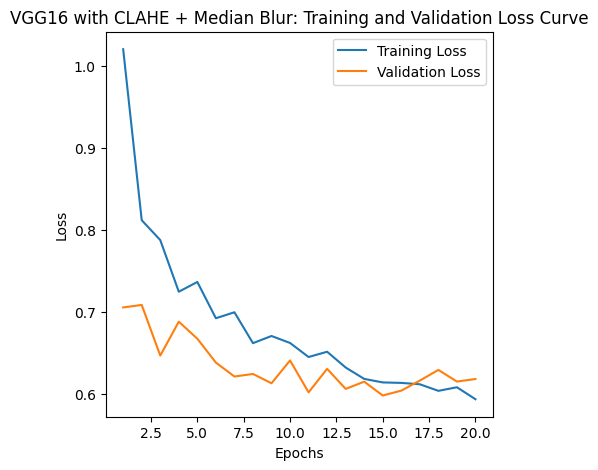

In [32]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_model_exp1.history, 'VGG16', 'CLAHE + Median Blur')

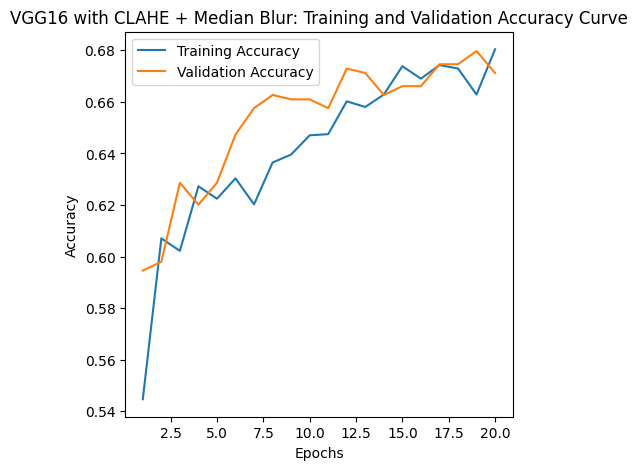

In [33]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_model_exp1.history, 'VGG16', 'CLAHE + Median Blur')

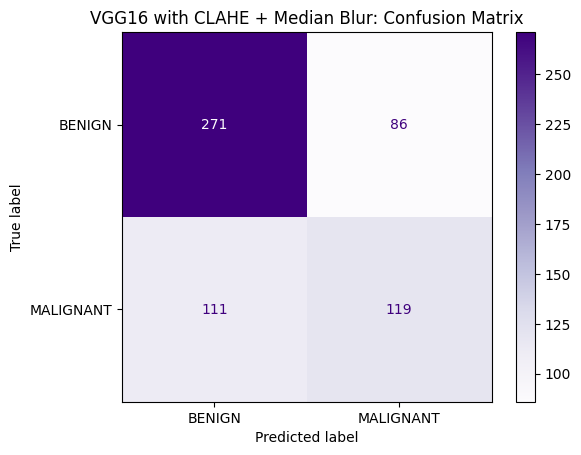

In [34]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_vgg_exp1, 'VGG16', 'CLAHE + Median Blur')

### ResNet50

In [35]:
# Create a ResNet50 model instance and compile it
resnet50_model_exp1 = create_resnet50_model()
resnet50_model_exp1 = compile_model(resnet50_model_exp1)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [36]:
# Print resnet50 model summary
resnet50_model_exp1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
# Train ResNet50 with training dataset for CLAHE + Median Blur preprocessor
resnet50_model_exp1.fit(
    train_dataset_exp1,
    validation_data=val_dataset_exp1,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 549ms/step - accuracy: 0.5960 - auc: 0.5816 - loss: 0.7077 - precision: 0.4895 - recall: 0.3883 - val_accuracy: 0.6457 - val_auc: 0.6473 - val_loss: 0.6036 - val_precision: 0.6310 - val_recall: 0.2304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 534ms/step - accuracy: 0.6242 - auc: 0.6324 - loss: 0.6447 - precision: 0.5391 - recall: 0.3739 - val_accuracy: 0.6865 - val_auc: 0.7146 - val_loss: 0.6206 - val_precision: 0.6027 - val_recall: 0.5870
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 527ms/step - accuracy: 0.6431 - auc: 0.6660 - loss: 0.6288 - precision: 0.5613 - recall: 0.4657 - val_accuracy: 0.6780 - val_auc: 0.7010 - val_loss: 0.5962 - val_precision: 0.6258 - val_recall: 0.4435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 501ms/step - accuracy: 0.6804 - auc: 0.6881 - loss: 0.6062 - precision: 0.6311 - recall: 0.4712 - val_accuracy: 0.6951 - val_auc: 0.7196 - val_loss: 0.5853 - val_precision: 0.6624 - val_recall: 0.4522
Epoch 5/20
72/72 ━━━━━━━━━━━

In [38]:
# Get validation logits
val_logits_resnet_exp1 = resnet50_model_exp1.predict(val_dataset_exp1)

# Get validation probabilities
val_probabilities_resnet_exp1 = tf.nn.sigmoid(val_logits_resnet_exp1)

# Get validation dataset predictions
val_predictions_resnet_exp1 = tf.cast(val_probabilities_resnet_exp1 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step


In [39]:
# Evaluation metrics
eval_metrics_resnet_exp1 = resnet50_model_exp1.evaluate(val_dataset_exp1, return_dict=True)
# F1 Score
f1_score_resnet_exp1 = compute_f1_score(eval_metrics_resnet_exp1['precision'], eval_metrics_resnet_exp1['recall'])
# Confusion Matrix
tn_resnet_exp1, fp_resnet_exp1, fn_resnet_exp1, tp_resnet_exp1 = confusion_matrix(val_true_labels, val_predictions_resnet_exp1).ravel()
# Specificity
specificity_resnet_exp1 = compute_specificity(tn_resnet_exp1, fp_resnet_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 438ms/step - accuracy: 0.7138 - auc: 0.7156 - loss: 0.5406 - precision: 0.7348 - recall: 0.4217


In [40]:
# Store evaluation metrics in a csv file
results_df_resnet_exp1 = generate_image_preprocessing_results_df(
    'ResNet50',
    'CLAHE + Median Blur',
    eval_metrics_resnet_exp1,
    specificity_resnet_exp1,
    f1_score_resnet_exp1)

store_image_experiment_results(results_file_path, results_df_resnet_exp1)

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


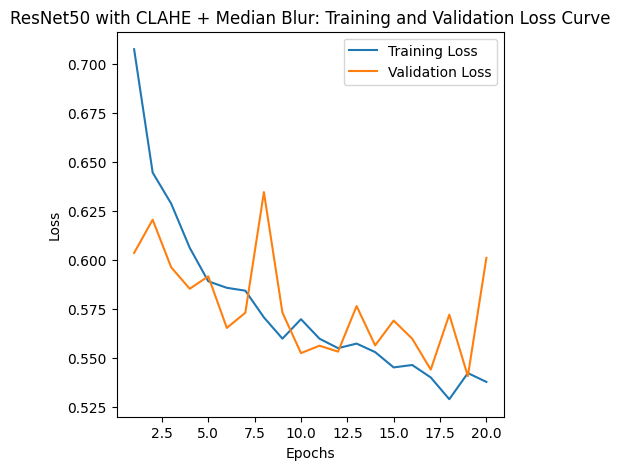

In [41]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_model_exp1.history, 'ResNet50', 'CLAHE + Median Blur')

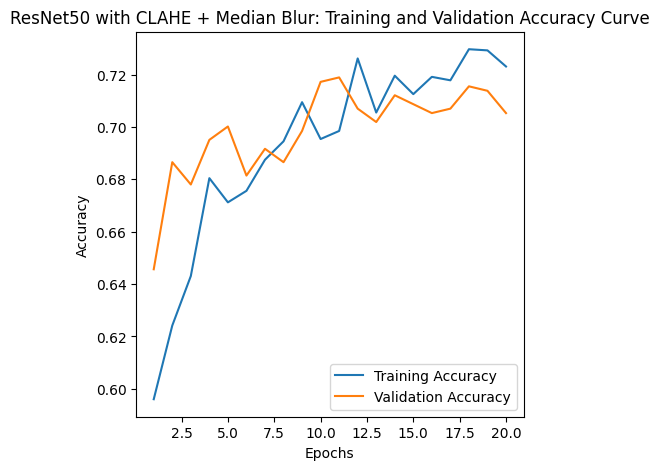

In [42]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_model_exp1.history, 'ResNet50', 'CLAHE + Median Blur')

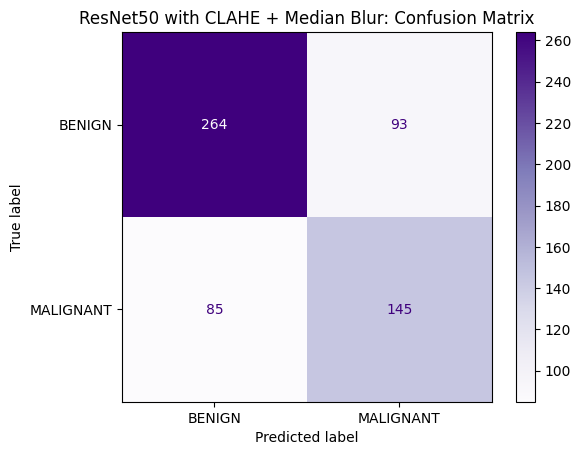

In [43]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_resnet_exp1, 'ResNet50', 'CLAHE + Median Blur')

### DenseNet121

In [44]:
# Create a DenseNet121 model instance and compile it
densenet121_model_exp1 = create_densenet121_model()
densenet121_model_exp1 = compile_model(densenet121_model_exp1)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
# Print DenseNet121 model summary
densenet121_model_exp1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [46]:
# Train DenseNet121 with training dataset for CLAHE + Median Blur preprocessor
densenet121_model_exp1.fit(
    train_dataset_exp1,
    validation_data=val_dataset_exp1,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 607ms/step - accuracy: 0.5468 - auc: 0.5285 - loss: 1.3779 - precision: 0.4303 - recall: 0.4336 - val_accuracy: 0.6320 - val_auc: 0.6013 - val_loss: 0.6796 - val_precision: 0.5556 - val_recall: 0.3043
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 531ms/step - accuracy: 0.5921 - auc: 0.5785 - loss: 1.0545 - precision: 0.4860 - recall: 0.4624 - val_accuracy: 0.6116 - val_auc: 0.5258 - val_loss: 0.7446 - val_precision: 0.6250 - val_recall: 0.0217
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 523ms/step - accuracy: 0.5947 - auc: 0.5723 - loss: 0.9685 - precision: 0.4888 - recall: 0.4347 - val_accuracy: 0.6457 - val_auc: 0.6237 - val_loss: 0.6425 - val_precision: 0.5786 - val_recall: 0.3522
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 508ms/step - accuracy: 0.5956 - auc: 0.5912 - loss: 0.8630 - precision: 0.4899 - recall: 0.4303 - val_accuracy: 0.6354 - val_auc: 0.6196 - val_loss: 0.6205 - val_precision: 0.5976 - val_recall: 0.2130
Epoch 5/20
72/72 ━━━━━━━━━━━

In [47]:
# Get validation logits
val_logits_densenet_exp1 = densenet121_model_exp1.predict(val_dataset_exp1)

# Get validation probabilities
val_probabilities_densenet_exp1 = tf.nn.sigmoid(val_logits_densenet_exp1)

# Get validation dataset predictions
val_predictions_densenet_exp1 = tf.cast(val_probabilities_densenet_exp1 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 957ms/step


In [48]:
# Evaluation metrics
eval_metrics_densenet_exp1 = densenet121_model_exp1.evaluate(val_dataset_exp1, return_dict=True)
# F1 Score
f1_score_densenet_exp1 = compute_f1_score(eval_metrics_densenet_exp1['precision'], eval_metrics_densenet_exp1['recall'])
# Confusion Matrix
tn_densenet_exp1, fp_densenet_exp1, fn_densenet_exp1, tp_densenet_exp1 = confusion_matrix(val_true_labels, val_predictions_densenet_exp1).ravel()
# Specificity
specificity_densenet_exp1 = compute_specificity(tn_densenet_exp1, fp_densenet_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step - accuracy: 0.6320 - auc: 0.6013 - loss: 0.6796 - precision: 0.5556 - recall: 0.3043


In [49]:
# Store evaluation metrics in a csv file
results_df_densenet_exp1 = generate_image_preprocessing_results_df(
    'DenseNet121',
    'CLAHE + Median Blur',
    eval_metrics_densenet_exp1,
    specificity_densenet_exp1,
    f1_score_densenet_exp1)

store_image_experiment_results(results_file_path, results_df_densenet_exp1)

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


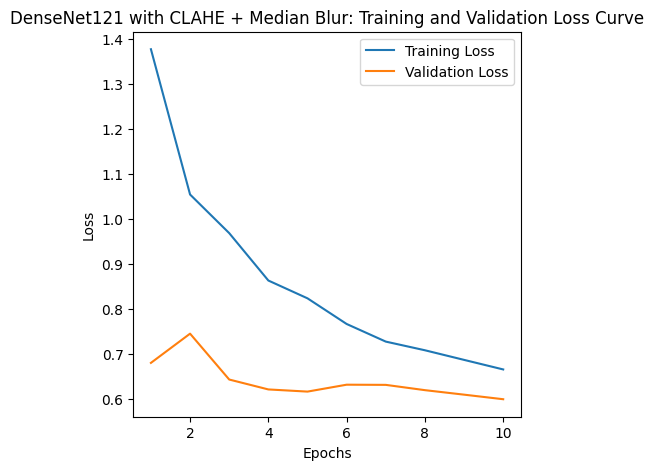

In [50]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_model_exp1.history, 'DenseNet121', 'CLAHE + Median Blur')

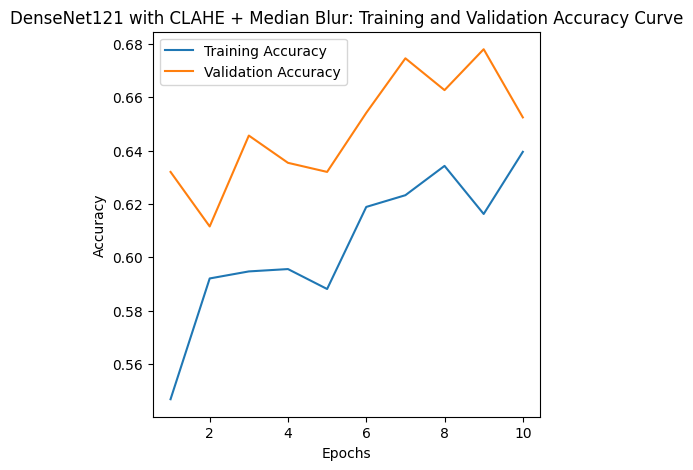

In [51]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_model_exp1.history, 'DenseNet121', 'CLAHE + Median Blur')

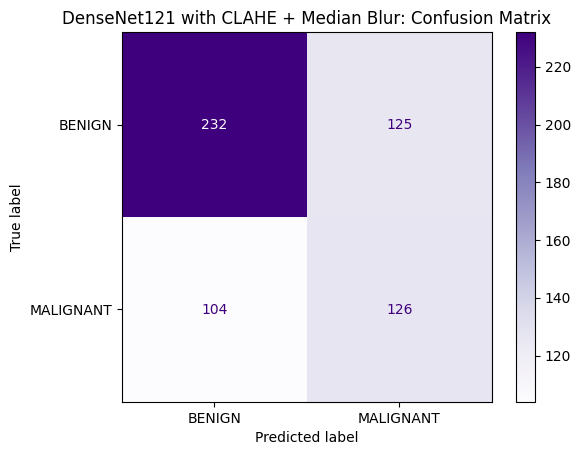

In [52]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_densenet_exp1, 'DenseNet121', 'CLAHE + Median Blur')

### MobileNetV2

In [53]:
# Create a MobileNetV2 model instance and compile it
mobilenetv2_model_exp1 = create_mobilenetv2_model()
mobilenetv2_model_exp1 = compile_model(mobilenetv2_model_exp1)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [54]:
# Print MobileNetV2 model summary
mobilenetv2_model_exp1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
# Train MobileNetV2 with training dataset for CLAHE + Median Blur preprocessor
mobilenetv2_model_exp1.fit(
    train_dataset_exp1,
    validation_data=val_dataset_exp1,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 505ms/step - accuracy: 0.5710 - auc: 0.5456 - loss: 0.7390 - precision: 0.4455 - recall: 0.3252 - val_accuracy: 0.6286 - val_auc: 0.6053 - val_loss: 0.6773 - val_precision: 0.5395 - val_recall: 0.3565
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 470ms/step - accuracy: 0.6163 - auc: 0.6100 - loss: 0.6868 - precision: 0.5249 - recall: 0.3617 - val_accuracy: 0.6218 - val_auc: 0.6231 - val_loss: 0.7027 - val_precision: 0.5196 - val_recall: 0.4609
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 466ms/step - accuracy: 0.6251 - auc: 0.6182 - loss: 0.6660 - precision: 0.5436 - recall: 0.3518 - val_accuracy: 0.6269 - val_auc: 0.6241 - val_loss: 0.6677 - val_precision: 0.5390 - val_recall: 0.3304
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 462ms/step - accuracy: 0.6233 - auc: 0.6090 - loss: 0.6761 - precision: 0.5403 - recall: 0.3485 - val_accuracy: 0.6371 - val_auc: 0.6200 - val_loss: 0.6580 - val_precision: 0.5612 - val_recall: 0.3391
Epoch 5/20
72/72 ━━━━━━━━━━━

In [56]:
# Get validation logits
val_logits_mobilenet_exp1 = mobilenetv2_model_exp1.predict(val_dataset_exp1)

# Get validation probabilities
val_probabilities_mobilenet_exp1 = tf.nn.sigmoid(val_logits_mobilenet_exp1)

# Get validation dataset predictions
val_predictions_mobilenet_exp1 = tf.cast(val_probabilities_mobilenet_exp1 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step


In [57]:
# Evaluation metrics
eval_metrics_mobilenet_exp1 = mobilenetv2_model_exp1.evaluate(val_dataset_exp1, return_dict=True)
# F1 Score
f1_score_mobilenet_exp1 = compute_f1_score(eval_metrics_mobilenet_exp1['precision'], eval_metrics_mobilenet_exp1['recall'])
# Confusion Matrix
tn_mobilenet_exp1, fp_mobilenet_exp1, fn_mobilenet_exp1, tp_mobilenet_exp1 = confusion_matrix(val_true_labels, val_predictions_mobilenet_exp1).ravel()
# Specificity
specificity_mobilenet_exp1 = compute_specificity(tn_mobilenet_exp1, fp_mobilenet_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step - accuracy: 0.6286 - auc: 0.6053 - loss: 0.6773 - precision: 0.5395 - recall: 0.3565


In [58]:
# Store evaluation metrics in a csv file
results_df_mobilenet_exp1 = generate_image_preprocessing_results_df(
    'MobileNetV2',
    'CLAHE + Median Blur',
    eval_metrics_mobilenet_exp1,
    specificity_mobilenet_exp1,
    f1_score_mobilenet_exp1)

store_image_experiment_results(results_file_path, results_df_mobilenet_exp1)

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


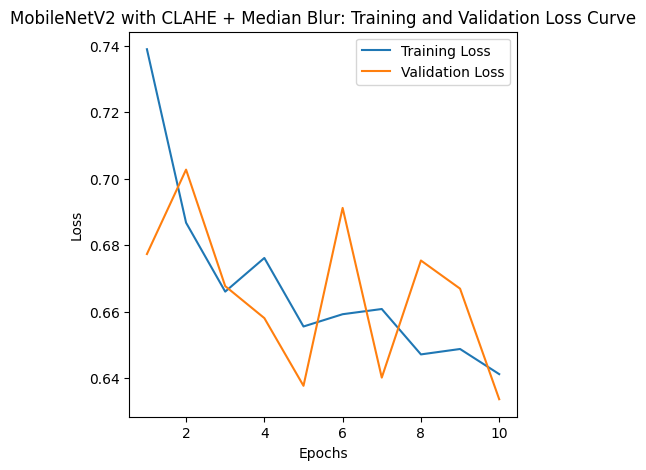

In [59]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_model_exp1.history, 'MobileNetV2', 'CLAHE + Median Blur')

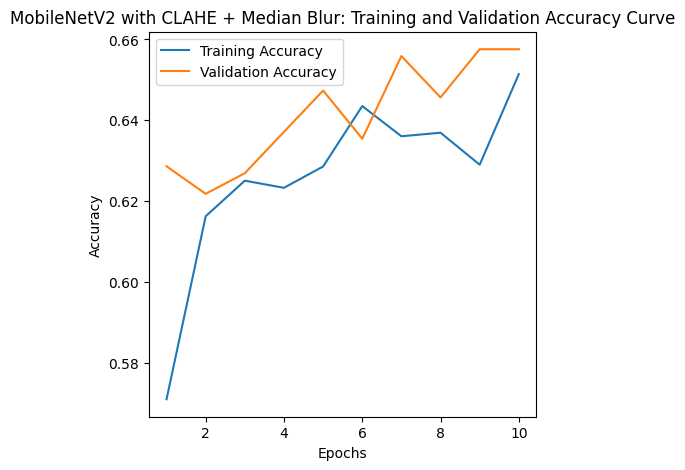

In [60]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_model_exp1.history, 'MobileNetV2', 'CLAHE + Median Blur')

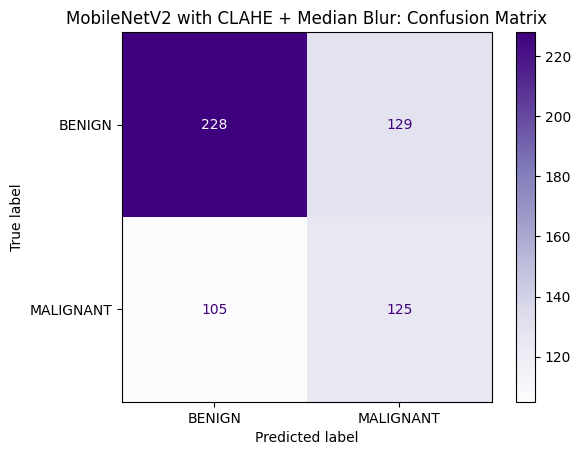

In [61]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_mobilenet_exp1, 'MobileNetV2', 'CLAHE + Median Blur')

### EfficientNet-B0

In [62]:
# Create a EfficientNetB0 model instance and compile it
efficientnetb0_model_exp1 = create_efficientnetb0_model()
efficientnetb0_model_exp1 = compile_model(efficientnetb0_model_exp1)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [63]:
# Print EfficientNetB0 model summary
efficientnetb0_model_exp1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [64]:
# Train EfficientNetB0 with training dataset for CLAHE + Median Blur preprocessor
efficientnetb0_model_exp1.fit(
    train_dataset_exp1,
    validation_data=val_dataset_exp1,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 755ms/step - accuracy: 0.6237 - auc: 0.6255 - loss: 0.6562 - precision: 0.5480 - recall: 0.3031 - val_accuracy: 0.6422 - val_auc: 0.6777 - val_loss: 0.6313 - val_precision: 0.5500 - val_recall: 0.4783
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 651ms/step - accuracy: 0.6589 - auc: 0.6710 - loss: 0.6194 - precision: 0.6168 - recall: 0.3739 - val_accuracy: 0.6695 - val_auc: 0.6976 - val_loss: 0.6281 - val_precision: 0.5891 - val_recall: 0.5174
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 483ms/step - accuracy: 0.6769 - auc: 0.6950 - loss: 0.6050 - precision: 0.6470 - recall: 0.4115 - val_accuracy: 0.6525 - val_auc: 0.6987 - val_loss: 0.6420 - val_precision: 0.5533 - val_recall: 0.5870
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 471ms/step - accuracy: 0.6738 - auc: 0.6879 - loss: 0.6050 - precision: 0.6337 - recall: 0.4248 - val_accuracy: 0.6695 - val_auc: 0.6969 - val_loss: 0.6373 - val_precision: 0.5789 - val_recall: 0.5739
Epoch 5/20
72/72 ━━━━━━━━━━━

In [65]:
# Get validation logits
val_logits_efficientnet_exp1 = efficientnetb0_model_exp1.predict(val_dataset_exp1)

# Get validation probabilities
val_probabilities_efficientnet_exp1 = tf.nn.sigmoid(val_logits_efficientnet_exp1)

# Get validation dataset predictions
val_predictions_efficientnet_exp1 = tf.cast(val_probabilities_efficientnet_exp1 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 649ms/step


In [66]:
# Evaluation metrics
eval_metrics_efficientnet_exp1 = efficientnetb0_model_exp1.evaluate(val_dataset_exp1, return_dict=True)
# F1 Score
f1_score_efficientnet_exp1 = compute_f1_score(eval_metrics_efficientnet_exp1['precision'], eval_metrics_efficientnet_exp1['recall'])
# Confusion Matrix
tn_efficientnet_exp1, fp_efficientnet_exp1, fn_efficientnet_exp1, tp_efficientnet_exp1 = confusion_matrix(val_true_labels, val_predictions_efficientnet_exp1).ravel()
# Specificity
specificity_efficientnet_exp1 = compute_specificity(tn_efficientnet_exp1, fp_efficientnet_exp1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.6422 - auc: 0.6777 - loss: 0.6313 - precision: 0.5500 - recall: 0.4783


In [67]:
# Store evaluation metrics in a csv file
results_df_efficientnet_exp1 = generate_image_preprocessing_results_df(
    'EfficientNet-B0',
    'CLAHE + Median Blur',
    eval_metrics_efficientnet_exp1,
    specificity_efficientnet_exp1,
    f1_score_efficientnet_exp1)

store_image_experiment_results(results_file_path, results_df_efficientnet_exp1)

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


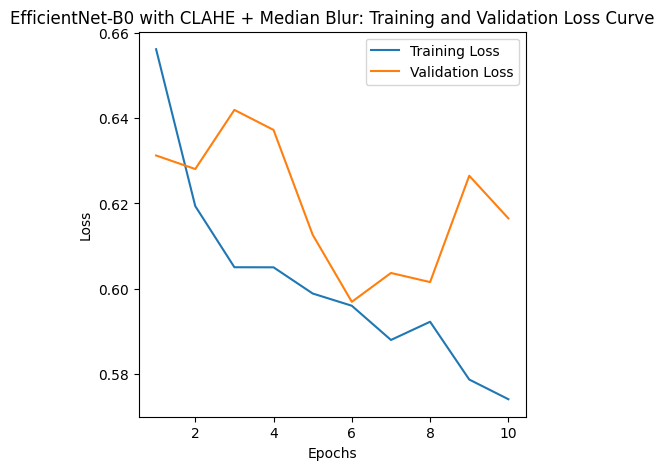

In [68]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_model_exp1.history, 'EfficientNet-B0', 'CLAHE + Median Blur')

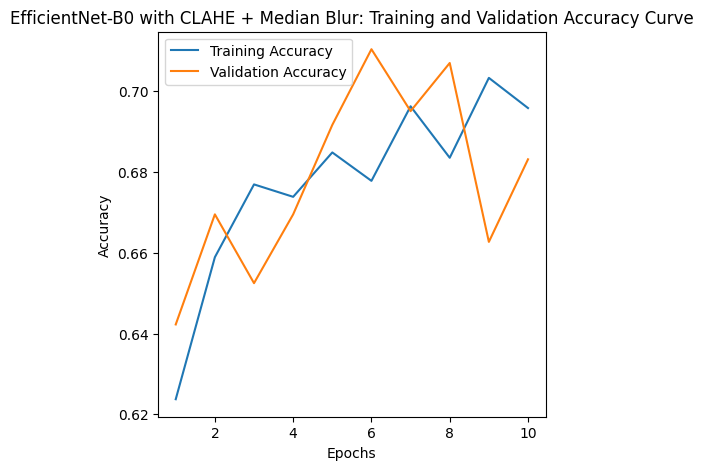

In [69]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_model_exp1.history, 'EfficientNet-B0', 'CLAHE + Median Blur')

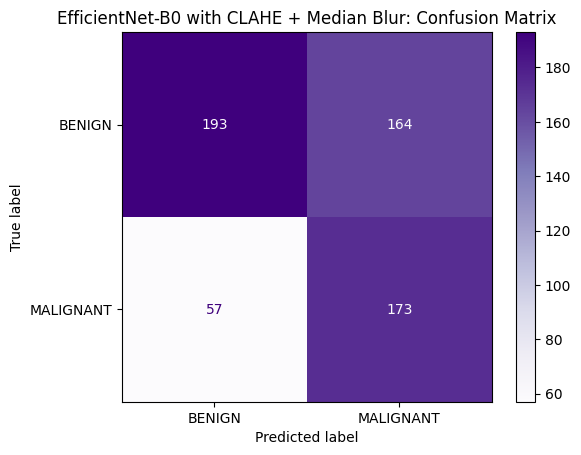

In [70]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_efficientnet_exp1, 'EfficientNet-B0', 'CLAHE + Median Blur')

## Histogram Equalization + Gaussian Blur Image Preprocessing Experiment

#### tf.data Dataset Preparation for Histogram Equalization + Gaussian Blur Preprocessing

In [17]:
# Histogram Equalization + Gaussian Blur + Baseline (resizing + model-specific normalization) preprocessing
histo_equalized_gauss_blur_preprocessor = IMAGE_PREPROCESSORS['histogram_equalization_gaussian_blur']

In [18]:
# Generate training dataset for the current image preprocessor
train_dataset_exp2 = generate_dataset(train_df, histo_equalized_gauss_blur_preprocessor)
# Shuffle training dataset samples
train_dataset_exp2 = shuffle_training_dataset(train_dataset_exp2, BUFFER_SIZE)
# Add data augmentation to training dataset
train_dataset_exp2 = data_augmented_dataset(train_dataset_exp2)
# Batch and prefetch the dataset
train_dataset_exp2 = batch_dataset(train_dataset_exp2, BATCH_SIZE)

# Generate validation dataset for the current image preprocessor
val_dataset_exp2 = generate_dataset(val_df, histo_equalized_gauss_blur_preprocessor)
# Batch and prefetch the validation dataset
val_dataset_exp2 = batch_dataset(val_dataset_exp2, BATCH_SIZE)

### VGG16

In [20]:
# Create a VGG16 model instance and compile it
vgg16_model_exp2 = create_vgg16_model()
vgg16_model_exp2 = compile_model(vgg16_model_exp2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
# Print vgg16 model summary
vgg16_model_exp2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
# Train VGG16 with training dataset for Histogram Equalization + Gaussian Blur preprocessor
vgg16_model_exp2.fit(
    train_dataset_exp2,
    validation_data=val_dataset_exp2,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 501ms/step - accuracy: 0.5552 - auc: 0.5450 - loss: 1.0394 - precision: 0.4433 - recall: 0.4668 - val_accuracy: 0.5860 - val_auc: 0.5746 - val_loss: 0.7183 - val_precision: 0.4629 - val_recall: 0.3522
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 500ms/step - accuracy: 0.5895 - auc: 0.5753 - loss: 0.9054 - precision: 0.4827 - recall: 0.4624 - val_accuracy: 0.6116 - val_auc: 0.5922 - val_loss: 0.6990 - val_precision: 0.5057 - val_recall: 0.3826
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 525ms/step - accuracy: 0.5996 - auc: 0.5823 - loss: 0.8454 - precision: 0.4959 - recall: 0.4679 - val_accuracy: 0.6388 - val_auc: 0.5865 - val_loss: 0.6543 - val_precision: 0.5882 - val_recall: 0.2609
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 519ms/step - accuracy: 0.6193 - auc: 0.6163 - loss: 0.7766 - precision: 0.5221 - recall: 0.4956 - val_accuracy: 0.6252 - val_auc: 0.6077 - val_loss: 0.6485 - val_precision: 0.5373 - val_recall: 0.3130
Epoch 5/20
72/72 ━━━━━━━━━━━

In [23]:
# Get validation logits
val_logits_vgg_exp2 = vgg16_model_exp2.predict(val_dataset_exp2)

# Get validation probabilities
val_probabilities_vgg_exp2 = tf.nn.sigmoid(val_logits_vgg_exp2)

# Get validation dataset predictions
val_predictions_vgg_exp2 = tf.cast(val_probabilities_vgg_exp2 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step


In [24]:
# Evaluation metrics
eval_metrics_vgg_exp2 = vgg16_model_exp2.evaluate(val_dataset_exp2, return_dict=True)
# F1 Score
f1_score_vgg_exp2 = compute_f1_score(eval_metrics_vgg_exp2['precision'], eval_metrics_vgg_exp2['recall'])
# Confusion Matrix
tn_vgg_exp2, fp_vgg_exp2, fn_vgg_exp2, tp_vgg_exp2 = confusion_matrix(val_true_labels, val_predictions_vgg_exp2).ravel()
# Specificity
specificity_vgg_exp2 = compute_specificity(tn_vgg_exp2, fp_vgg_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 432ms/step - accuracy: 0.6593 - auc: 0.6442 - loss: 0.5948 - precision: 0.6389 - recall: 0.3000


In [25]:
# Store evaluation metrics in a csv file
results_df_vgg_exp2 = generate_image_preprocessing_results_df(
    'VGG16',
    'Histogram Equalization + Gaussian Blur',
    eval_metrics_vgg_exp2,
    specificity_vgg_exp2,
    f1_score_vgg_exp2)

store_image_experiment_results(results_file_path, results_df_vgg_exp2)

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


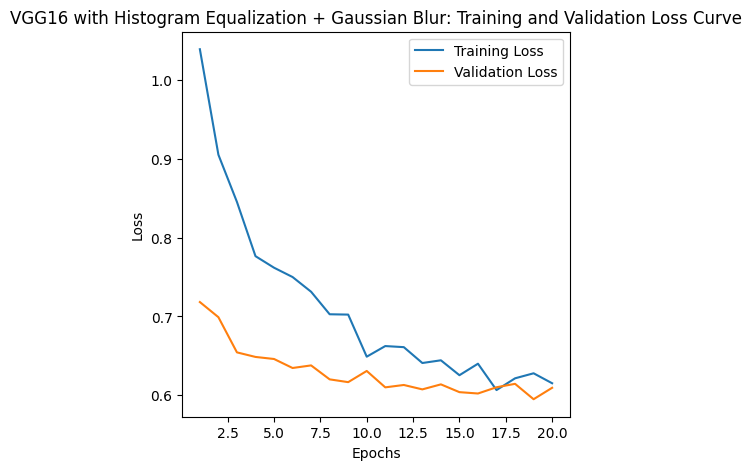

In [26]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_model_exp2.history, 'VGG16', 'Histogram Equalization + Gaussian Blur')

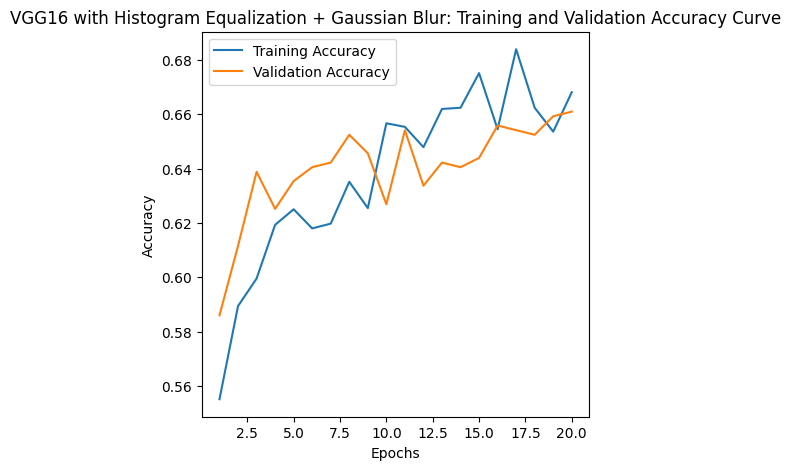

In [27]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_model_exp2.history, 'VGG16', 'Histogram Equalization + Gaussian Blur')

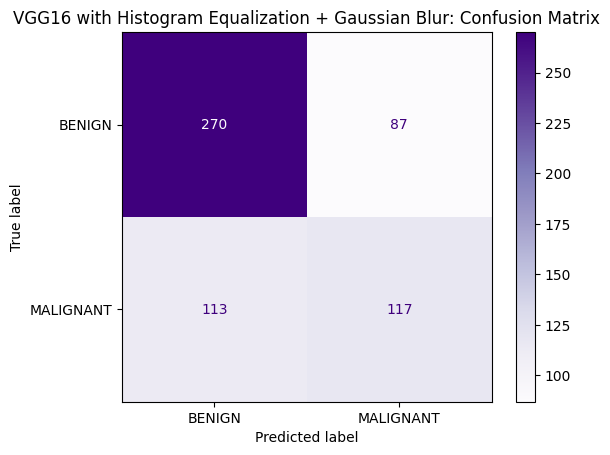

In [28]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_vgg_exp2, 'VGG16', 'Histogram Equalization + Gaussian Blur')

### ResNet50

In [29]:
# Create a ResNet50 model instance and compile it
resnet50_model_exp2 = create_resnet50_model()
resnet50_model_exp2 = compile_model(resnet50_model_exp2)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [30]:
# Print resnet50 model summary
resnet50_model_exp2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
# Train ResNet50 with training dataset for Histogram Equalization + Gaussian Blur preprocessor
resnet50_model_exp2.fit(
    train_dataset_exp2,
    validation_data=val_dataset_exp2,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 571ms/step - accuracy: 0.6119 - auc: 0.5954 - loss: 0.7093 - precision: 0.5149 - recall: 0.4027 - val_accuracy: 0.6780 - val_auc: 0.6691 - val_loss: 0.5984 - val_precision: 0.6952 - val_recall: 0.3174
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 481ms/step - accuracy: 0.6396 - auc: 0.6334 - loss: 0.6658 - precision: 0.5593 - recall: 0.4381 - val_accuracy: 0.6780 - val_auc: 0.7043 - val_loss: 0.5910 - val_precision: 0.6145 - val_recall: 0.4783
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 480ms/step - accuracy: 0.6585 - auc: 0.6693 - loss: 0.6344 - precision: 0.5896 - recall: 0.4624 - val_accuracy: 0.6763 - val_auc: 0.7105 - val_loss: 0.6053 - val_precision: 0.5885 - val_recall: 0.5783
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 480ms/step - accuracy: 0.6809 - auc: 0.6879 - loss: 0.6128 - precision: 0.6294 - recall: 0.4790 - val_accuracy: 0.6968 - val_auc: 0.6950 - val_loss: 0.5668 - val_precision: 0.7281 - val_recall: 0.3609
Epoch 5/20
72/72 ━━━━━━━━━━━

In [32]:
# Get validation logits
val_logits_resnet_exp2 = resnet50_model_exp2.predict(val_dataset_exp2)

# Get validation probabilities
val_probabilities_resnet_exp2 = tf.nn.sigmoid(val_logits_resnet_exp2)

# Get validation dataset predictions
val_predictions_resnet_exp2 = tf.cast(val_probabilities_resnet_exp2 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 365ms/step


In [33]:
# Evaluation metrics
eval_metrics_resnet_exp2 = resnet50_model_exp2.evaluate(val_dataset_exp2, return_dict=True)
# F1 Score
f1_score_resnet_exp2 = compute_f1_score(eval_metrics_resnet_exp2['precision'], eval_metrics_resnet_exp2['recall'])
# Confusion Matrix
tn_resnet_exp2, fp_resnet_exp2, fn_resnet_exp2, tp_resnet_exp2 = confusion_matrix(val_true_labels, val_predictions_resnet_exp2).ravel()
# Specificity
specificity_resnet_exp2 = compute_specificity(tn_resnet_exp2, fp_resnet_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.6917 - auc: 0.6864 - loss: 0.5417 - precision: 0.7882 - recall: 0.2913


In [34]:
# Store evaluation metrics in a csv file
results_df_resnet_exp2 = generate_image_preprocessing_results_df(
    'ResNet50',
    'Histogram Equalization + Gaussian Blur',
    eval_metrics_resnet_exp2,
    specificity_resnet_exp2,
    f1_score_resnet_exp2)

store_image_experiment_results(results_file_path, results_df_resnet_exp2)

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


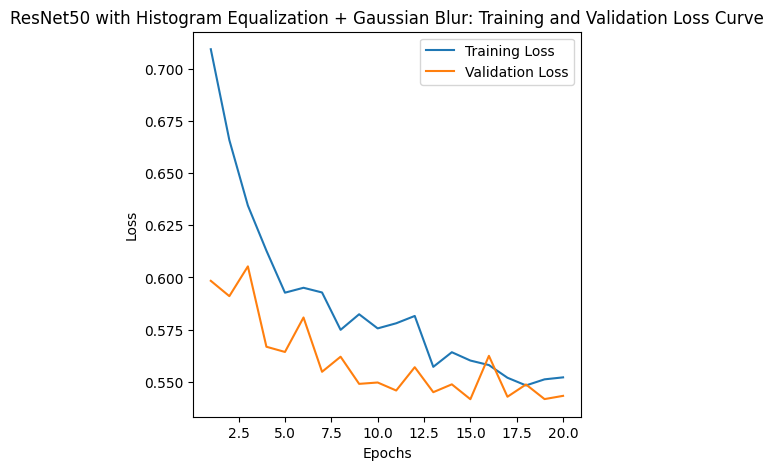

In [35]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_model_exp2.history, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

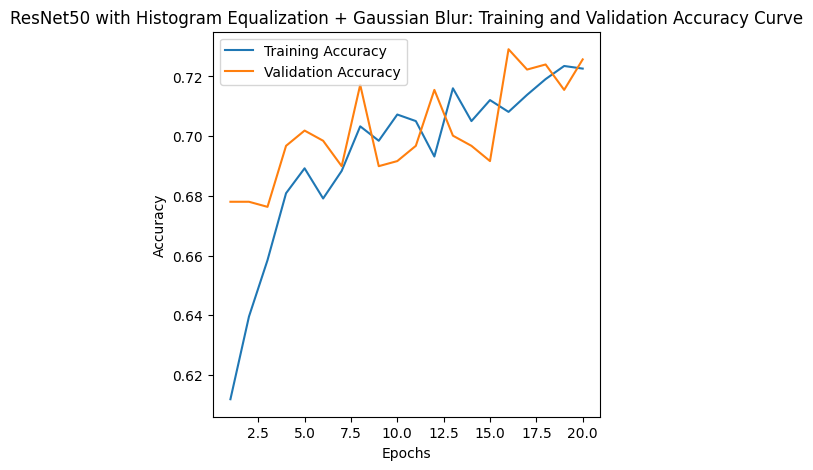

In [36]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_model_exp2.history, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

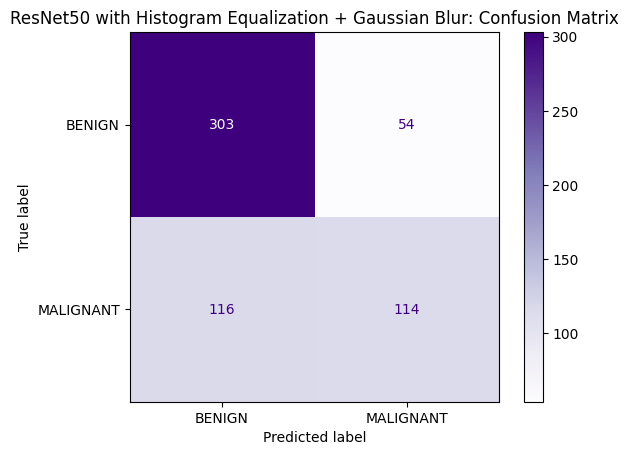

In [37]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_resnet_exp2, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

### DenseNet121

In [38]:
# Create a DenseNet121 model instance and compile it
densenet121_model_exp2 = create_densenet121_model()
densenet121_model_exp2 = compile_model(densenet121_model_exp2)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
# Print DenseNet121 model summary
densenet121_model_exp2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [40]:
# Train DenseNet121 with training dataset for Histogram Equalization + Gaussian Blur preprocessor
densenet121_model_exp2.fit(
    train_dataset_exp2,
    validation_data=val_dataset_exp2,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 576ms/step - accuracy: 0.5477 - auc: 0.5384 - loss: 1.3604 - precision: 0.4359 - recall: 0.4701 - val_accuracy: 0.6252 - val_auc: 0.6214 - val_loss: 0.6799 - val_precision: 0.5329 - val_recall: 0.3522
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 493ms/step - accuracy: 0.5767 - auc: 0.5693 - loss: 1.1046 - precision: 0.4676 - recall: 0.4712 - val_accuracy: 0.6116 - val_auc: 0.6174 - val_loss: 0.7428 - val_precision: 0.5040 - val_recall: 0.5522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 488ms/step - accuracy: 0.5899 - auc: 0.5776 - loss: 0.9153 - precision: 0.4836 - recall: 0.4735 - val_accuracy: 0.6746 - val_auc: 0.6567 - val_loss: 0.6186 - val_precision: 0.6560 - val_recall: 0.3565
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 491ms/step - accuracy: 0.6004 - auc: 0.5891 - loss: 0.8234 - precision: 0.4969 - recall: 0.4469 - val_accuracy: 0.6865 - val_auc: 0.6712 - val_loss: 0.6046 - val_precision: 0.6855 - val_recall: 0.3696
Epoch 5/20
72/72 ━━━━━━━━━━━

In [41]:
# Get validation logits
val_logits_densenet_exp2 = densenet121_model_exp2.predict(val_dataset_exp2)

# Get validation probabilities
val_probabilities_densenet_exp2 = tf.nn.sigmoid(val_logits_densenet_exp2)

# Get validation dataset predictions
val_predictions_densenet_exp2 = tf.cast(val_probabilities_densenet_exp2 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 693ms/step


In [42]:
# Evaluation metrics
eval_metrics_densenet_exp2 = densenet121_model_exp2.evaluate(val_dataset_exp2, return_dict=True)
# F1 Score
f1_score_densenet_exp2 = compute_f1_score(eval_metrics_densenet_exp2['precision'], eval_metrics_densenet_exp2['recall'])
# Confusion Matrix
tn_densenet_exp2, fp_densenet_exp2, fn_densenet_exp2, tp_densenet_exp2 = confusion_matrix(val_true_labels, val_predictions_densenet_exp2).ravel()
# Specificity
specificity_densenet_exp2 = compute_specificity(tn_densenet_exp2, fp_densenet_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.6252 - auc: 0.6214 - loss: 0.6799 - precision: 0.5329 - recall: 0.3522


In [43]:
# Store evaluation metrics in a csv file
results_df_densenet_exp2 = generate_image_preprocessing_results_df(
    'DenseNet121',
    'Histogram Equalization + Gaussian Blur',
    eval_metrics_densenet_exp2,
    specificity_densenet_exp2,
    f1_score_densenet_exp2)
store_image_experiment_results(results_file_path, results_df_densenet_exp2)

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


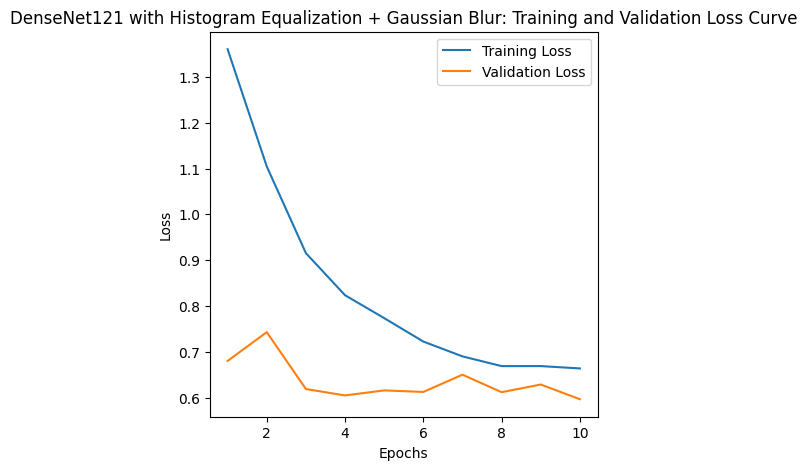

In [44]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_model_exp2.history, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

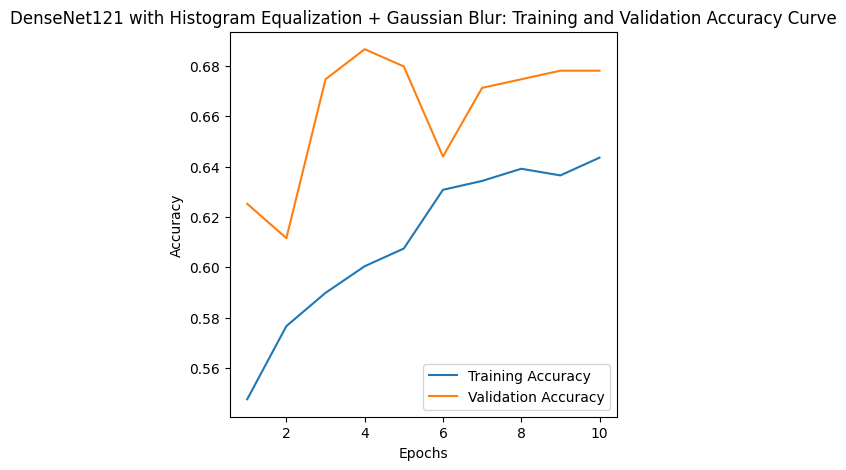

In [45]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_model_exp2.history, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

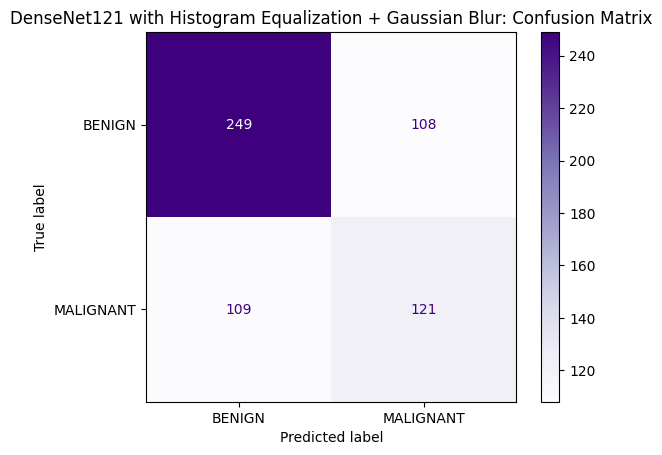

In [46]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_densenet_exp2, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

### MobileNetV2

In [47]:
# Create a MobileNetV2 model instance and compile it
mobilenetv2_model_exp2 = create_mobilenetv2_model()
mobilenetv2_model_exp2 = compile_model(mobilenetv2_model_exp2)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
# Print MobileNetV2 model summary
mobilenetv2_model_exp2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [49]:
# Train MobileNetV2 with training dataset for Histogram Equalization + Gaussian Blur preprocessor
mobilenetv2_model_exp2.fit(
    train_dataset_exp2,
    validation_data=val_dataset_exp2,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 435ms/step - accuracy: 0.5547 - auc: 0.5203 - loss: 0.7625 - precision: 0.4155 - recall: 0.2965 - val_accuracy: 0.6440 - val_auc: 0.6441 - val_loss: 0.6444 - val_precision: 0.6842 - val_recall: 0.1696
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 418ms/step - accuracy: 0.5952 - auc: 0.5624 - loss: 0.7176 - precision: 0.4850 - recall: 0.3031 - val_accuracy: 0.6627 - val_auc: 0.6588 - val_loss: 0.6266 - val_precision: 0.7286 - val_recall: 0.2217
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 413ms/step - accuracy: 0.6004 - auc: 0.5847 - loss: 0.6901 - precision: 0.4957 - recall: 0.3164 - val_accuracy: 0.6235 - val_auc: 0.6264 - val_loss: 0.6244 - val_precision: 0.6957 - val_recall: 0.0696
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 408ms/step - accuracy: 0.6132 - auc: 0.6032 - loss: 0.6788 - precision: 0.5217 - recall: 0.3186 - val_accuracy: 0.6474 - val_auc: 0.6507 - val_loss: 0.6225 - val_precision: 0.7255 - val_recall: 0.1609
Epoch 5/20
72/72 ━━━━━━━━━━━

In [50]:
# Get validation logits
val_logits_mobilenet_exp2 = mobilenetv2_model_exp2.predict(val_dataset_exp2)

# Get validation probabilities
val_probabilities_mobilenet_exp2 = tf.nn.sigmoid(val_logits_mobilenet_exp2)

# Get validation dataset predictions
val_predictions_mobilenet_exp2 = tf.cast(val_probabilities_mobilenet_exp2 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step


In [51]:
# Evaluation metrics
eval_metrics_mobilenet_exp2 = mobilenetv2_model_exp2.evaluate(val_dataset_exp2, return_dict=True)
# F1 Score
f1_score_mobilenet_exp2 = compute_f1_score(eval_metrics_mobilenet_exp2['precision'], eval_metrics_mobilenet_exp2['recall'])
# Confusion Matrix
tn_mobilenet_exp2, fp_mobilenet_exp2, fn_mobilenet_exp2, tp_mobilenet_exp2 = confusion_matrix(val_true_labels, val_predictions_mobilenet_exp2).ravel()
# Specificity
specificity_mobilenet_exp2 = compute_specificity(tn_mobilenet_exp2, fp_mobilenet_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.6440 - auc: 0.6441 - loss: 0.6444 - precision: 0.6842 - recall: 0.1696


In [52]:
# Store evaluation metrics in a csv file
results_df_mobilenet_exp2 = generate_image_preprocessing_results_df(
    'MobileNetV2',
    'Histogram Equalization + Gaussian Blur',
    eval_metrics_mobilenet_exp2,
    specificity_mobilenet_exp2,
    f1_score_mobilenet_exp2)
store_image_experiment_results(results_file_path, results_df_mobilenet_exp2)

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


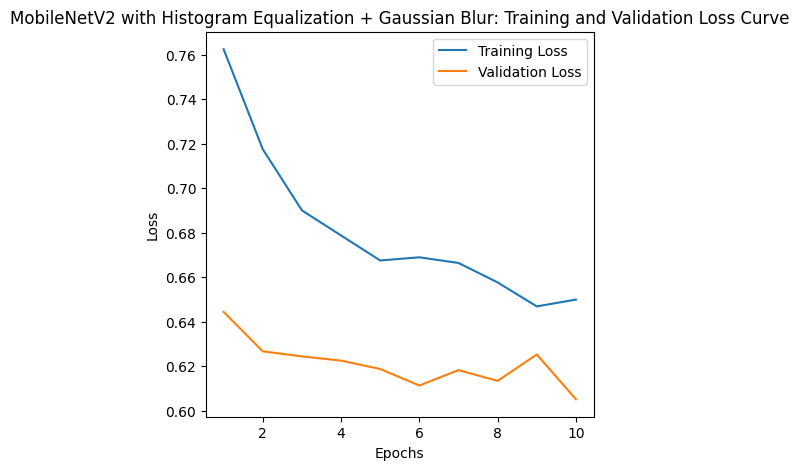

In [53]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_model_exp2.history, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

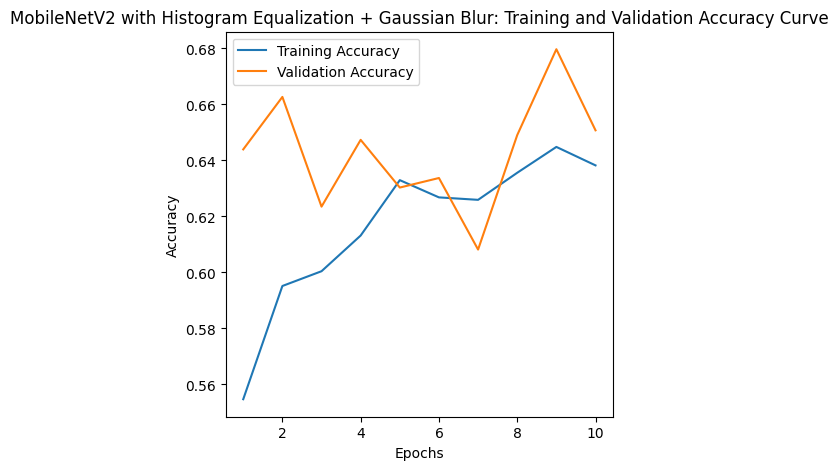

In [54]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_model_exp2.history, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

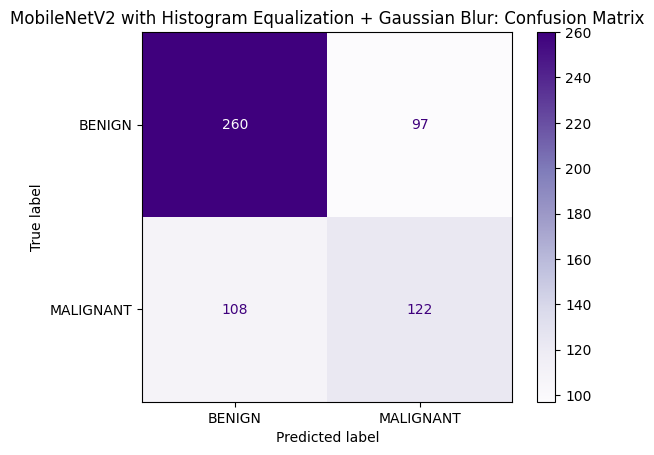

In [55]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_mobilenet_exp2, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

### EfficientNet-B0

In [56]:
# Create a EfficientNetB0 model instance and compile it
efficientnetb0_model_exp2 = create_efficientnetb0_model()
efficientnetb0_model_exp2 = compile_model(efficientnetb0_model_exp2)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [57]:
# Print EfficientNetB0 model summary
efficientnetb0_model_exp2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [58]:
# Train EfficientNetB0 with training dataset for Histogram Equalization + Gaussian Blur preprocessor
efficientnetb0_model_exp2.fit(
    train_dataset_exp2,
    validation_data=val_dataset_exp2,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 476ms/step - accuracy: 0.6343 - auc: 0.6168 - loss: 0.6637 - precision: 0.5914 - recall: 0.2577 - val_accuracy: 0.6712 - val_auc: 0.6849 - val_loss: 0.6107 - val_precision: 0.6609 - val_recall: 0.3304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 446ms/step - accuracy: 0.6541 - auc: 0.6603 - loss: 0.6285 - precision: 0.6077 - recall: 0.3650 - val_accuracy: 0.6763 - val_auc: 0.7110 - val_loss: 0.6051 - val_precision: 0.6493 - val_recall: 0.3783
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 432ms/step - accuracy: 0.6580 - auc: 0.6764 - loss: 0.6181 - precision: 0.6141 - recall: 0.3750 - val_accuracy: 0.6831 - val_auc: 0.7055 - val_loss: 0.5921 - val_precision: 0.6864 - val_recall: 0.3522
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 439ms/step - accuracy: 0.6620 - auc: 0.6662 - loss: 0.6181 - precision: 0.6248 - recall: 0.3739 - val_accuracy: 0.6763 - val_auc: 0.7228 - val_loss: 0.6135 - val_precision: 0.5901 - val_recall: 0.5696
Epoch 5/20
72/72 ━━━━━━━━━━━

In [59]:
# Get validation logits
val_logits_efficientnet_exp2 = efficientnetb0_model_exp2.predict(val_dataset_exp2)

# Get validation probabilities
val_probabilities_efficientnet_exp2 = tf.nn.sigmoid(val_logits_efficientnet_exp2)

# Get validation dataset predictions
val_predictions_efficientnet_exp2 = tf.cast(val_probabilities_efficientnet_exp2 >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step


In [60]:
# Evaluation metrics
eval_metrics_efficientnet_exp2 = efficientnetb0_model_exp2.evaluate(val_dataset_exp2, return_dict=True)
# F1 Score
f1_score_efficientnet_exp2 = compute_f1_score(eval_metrics_efficientnet_exp2['precision'], eval_metrics_efficientnet_exp2['recall'])
# Confusion Matrix
tn_efficientnet_exp2, fp_efficientnet_exp2, fn_efficientnet_exp2, tp_efficientnet_exp2 = confusion_matrix(val_true_labels, val_predictions_efficientnet_exp2).ravel()
# Specificity
specificity_efficientnet_exp2 = compute_specificity(tn_efficientnet_exp2, fp_efficientnet_exp2)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 351ms/step - accuracy: 0.6712 - auc: 0.6849 - loss: 0.6107 - precision: 0.6609 - recall: 0.3304


In [61]:
# Store evaluation metrics in a csv file
results_df_efficientnet_exp2 = generate_image_preprocessing_results_df(
    'EfficientNet-B0',
    'Histogram Equalization + Gaussian Blur',
    eval_metrics_efficientnet_exp2,
    specificity_efficientnet_exp2,
    f1_score_efficientnet_exp2)
store_image_experiment_results(results_file_path, results_df_efficientnet_exp2)

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


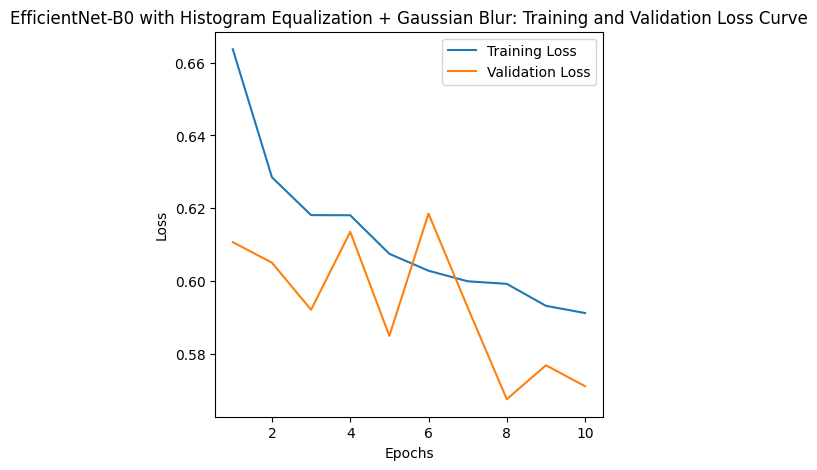

In [62]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_model_exp2.history, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')

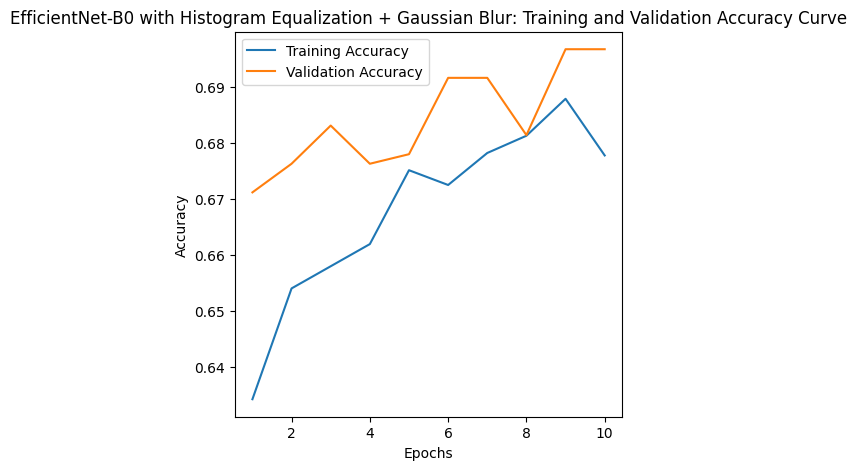

In [63]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_model_exp2.history, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')

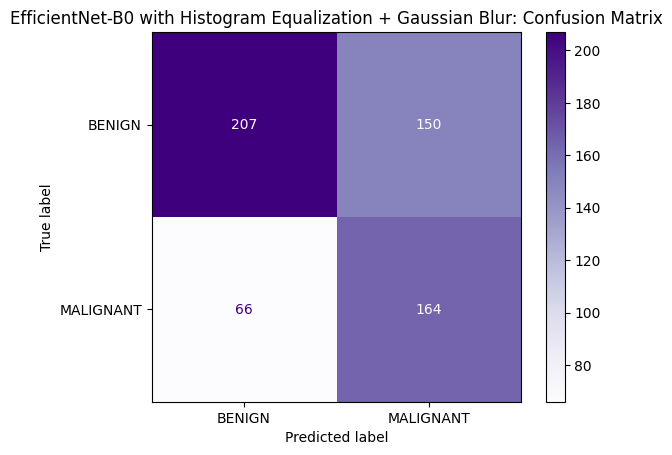

In [64]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_efficientnet_exp2, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')